# Notebook for Unsupervised ML: Detecting conservation laws

Corrected validated version with two post-hoc physics checks.

Main correction: the PCA object used for preprocessing is now stored as `preprocess_pca` and is not overwritten by later diagnostic PCA fits. The final energy validation maps processed coordinates back to raw `[x, v]` coordinates using this original preprocessing transform.


- Code taken and adapted from: https://github.com/KindXiaoming/aipoincare/blob/master/backend/training.py
- Dataset and code inspired by: https://github.com/KindXiaoming/aipoincare/
- ChatGPT assistance (30 Sept 2025 and 5 May 2026)

## Set up working tree and load packages

In [1]:
# --------------------- Import necessary libraries ---------------------
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import os
from sklearn.decomposition import PCA
import torch.optim as optim
import copy

# set seeds to make outputs reproducible
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [2]:
# --------------------- Set hyperparameters and data config ---------------------

# Hidden layer widths for the neural network; first and last layer are added later
nn_widths = [256, 256]  # Two hidden layers: 64 units and 32 units
hidden_depth = len(nn_widths)
# Negative slope for LeakyReLU activation function
slope = 0.1
# List of noise magnitudes (sigmal) to test during training
sigmals = [1e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 10.0]
# Optimizer type: 'Adam' or 'SGD'
opt = 'Adam'
# Learning rate for optimizer
lr = 0.001
# Mini-batch size for training
batch_size = 64
# Number of training iterations (epochs)
epoch = 5000
# ERD parameter `a` for computing effective dimensionality
a = 2
# Path to the input data file (must be a .txt file of shape [n_samples, n_features])
model = 'harmonic_1d.txt'
# Number of random walks to simulate for post-training variance analysis
n_walk = 600

[[ 1.4142135  -0.        ]
 [ 1.414102   -0.01777106]
 [ 1.413767   -0.03553932]
 ...
 [ 1.4132087   0.05330197]
 [ 1.413767    0.03553932]
 [ 1.414102    0.01777106]] 4000 2


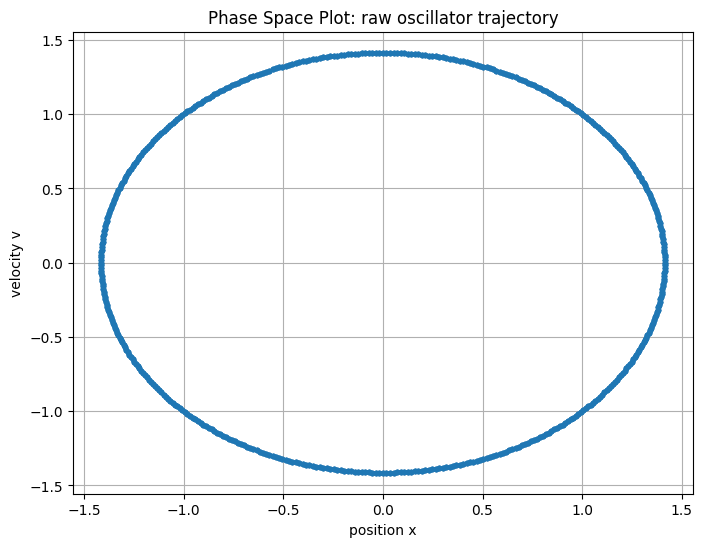

In [3]:
# --------------------- Load and preprocess the data ---------------------

# Load dataset as NumPy array.
# The raw coordinates are kept for the physics validation at the end of the notebook.
xs_raw = np.loadtxt(model).astype(np.float32)
xs = xs_raw.copy()

n_train = xs.shape[0]       # Number of samples
input_dim = xs.shape[1]     # Dimensionality of input features

# Show data set and plot phase space
print(xs_raw, n_train, input_dim)

plt.figure(figsize=(8, 6))
plt.plot(xs_raw[:, 0], xs_raw[:, 1], '.', alpha=0.6)
plt.title("Phase Space Plot: raw oscillator trajectory")
plt.xlabel("position x")
plt.ylabel("velocity v")
plt.grid(True)
plt.show()

In [4]:
# Step 1: Normalize each input feature to zero mean and unit variance.
# We store mean and standard deviation so that validation points can later be
# transformed back to physical coordinates.
raw_mean = xs_raw.mean(axis=0)
raw_std = xs_raw.std(axis=0)
raw_std[raw_std == 0] = 1.0

xs = (xs_raw - raw_mean[np.newaxis, :]) / raw_std[np.newaxis, :]

# Sanity check that mean = 0, and std = 1
np.round(xs.mean(axis=0), 3), np.round(xs.std(axis=0), 3)

(array([0., 0.], dtype=float32), array([1., 1.], dtype=float32))

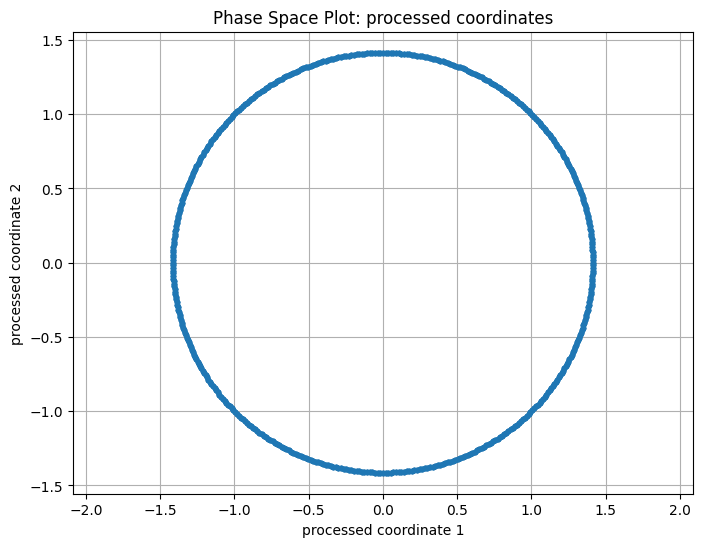

In [5]:
# Step 2: Apply PCA (rotation only, no scaling) to decorrelate dimensions.
# IMPORTANT: keep this object for inverse_preprocess() in the validation cells.
# Do not overwrite it with later diagnostic PCA objects.
preprocess_pca = PCA()
xs = preprocess_pca.fit_transform(xs)

# Plot transformed data
plt.figure(figsize=(8, 6))
plt.plot(xs[:, 0], xs[:, 1], '.', alpha=0.6)
plt.title("Phase Space Plot: processed coordinates")
plt.xlabel("processed coordinate 1")
plt.ylabel("processed coordinate 2")
plt.axis("equal")
plt.grid(True)
plt.show()


In [6]:
# Build the entire hidden dimensions of the NN:
nn_widths.insert(0, input_dim)
nn_widths.append(input_dim)
print( nn_widths )

[2, 256, 256, 2]


# Training

## Understanding the pull network

The network can be understood as a **pull network**: it learns a vector field that points noisy samples back toward the data manifold.

Assume we start from a clean training point $x \in \mathbb{R}^d$ and add Gaussian noise $\varepsilon \sim \mathcal{N}(0, \sigma^2 I).$ The noisy input to the network is therefore $\tilde{x} = x + \varepsilon.$

To recover the original clean point \(x\), we need to add the vector $-\varepsilon.$ Indeed,

$$
\tilde{x} + (-\varepsilon)
=
(x + \varepsilon) - \varepsilon
=
x.
$$

So the ideal correction vector is $x - \tilde{x} = -\varepsilon.$

The neural network is trained to predict exactly this correction vector. If the network is denoted by $f_\theta,$ then the goal is

$$
f_\theta(\tilde{x}) \approx -\varepsilon.
$$

Equivalently,

$$
f_\theta(\tilde{x}) \approx x - \tilde{x}.
$$

That is why the training target in the code is

```python
loss = criterion(outputs, -perturb)

In [7]:
# --------------------- Training loop across different noise levels ---------------------
exps = []   # To store explained variance ratios
losses = [] # To record loss values during training

for sigmal in sigmals:
    # Define a new neural network (as a list of layers) for each noise level
    linears = [nn.Linear(nn_widths[i], nn_widths[i + 1]) for i in range(hidden_depth + 1)]
    parameters = [p for layer in linears for p in layer.parameters()]  # Collect all trainable parameters

    # Define loss function
    criterion = nn.MSELoss()

    # Choose optimizer
    optimizer = optim.Adam(parameters, lr=lr) if opt == "Adam" else optim.SGD(parameters, lr=lr)

    print(f"sigmal = {sigmal}")

    # --------------------- Training the denoising network ---------------------
    # (see in the Appendix below a step by step explanation of these steps)
    
    for j in range(epoch):
        # Randomly sample a batch of training data
        choices = np.random.choice(n_train, batch_size)
        perturb = torch.normal(0, sigmal, size=(batch_size, input_dim))  # Add Gaussian noise
        inputs0 = torch.tensor(xs[choices], dtype=torch.float) + perturb  # Noisy input

        # Forward pass through each layer using LeakyReLU
        x = inputs0
        act = nn.LeakyReLU(slope)
        for i in range(hidden_depth):
            x = act(linears[i](x))
        outputs = linears[hidden_depth](x)  # Final layer (no activation)

        # Training objective: recover the *negative* of the noise added
        loss = criterion(outputs, -perturb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(float(loss.data))

        if j % 200 == 0:
            print(f"Epoch {j} | Loss: {loss:.4f}")

    # --------------------- Perform stochastic walks using trained network ---------------------
    x0 = copy.deepcopy(xs[int(n_train / 2)])  # Start from a central data point
    x0 = x0[np.newaxis, :]
    x0 = x0 + np.random.randn(n_walk, input_dim) * sigmal  # Add noise

    # Pass walk samples through trained denoising network
    x = torch.tensor(x0, dtype=torch.float)
    for i in range(hidden_depth):
        x = act(linears[i](x))
    x = linears[hidden_depth](x)
    x0 = x0 + x.detach().numpy()  # Apply learned correction

    # --------------------- Compute explained variance ratio via PCA ---------------------
    walk_pca = PCA()
    walk_pca.fit(x0)
    svs = walk_pca.singular_values_
    exp_ratio = svs**2 / np.sum(svs**2)
    exps.append(exp_ratio)

# Stack results into a NumPy array
exps = np.array(exps)

sigmal = 0.001
Epoch 0 | Loss: 0.0195
Epoch 200 | Loss: 0.0000
Epoch 400 | Loss: 0.0000
Epoch 600 | Loss: 0.0001
Epoch 800 | Loss: 0.0000
Epoch 1000 | Loss: 0.0000
Epoch 1200 | Loss: 0.0000
Epoch 1400 | Loss: 0.0000
Epoch 1600 | Loss: 0.0000
Epoch 1800 | Loss: 0.0000
Epoch 2000 | Loss: 0.0000
Epoch 2200 | Loss: 0.0000
Epoch 2400 | Loss: 0.0000
Epoch 2600 | Loss: 0.0000
Epoch 2800 | Loss: 0.0000
Epoch 3000 | Loss: 0.0000
Epoch 3200 | Loss: 0.0000
Epoch 3400 | Loss: 0.0000
Epoch 3600 | Loss: 0.0000
Epoch 3800 | Loss: 0.0000
Epoch 4000 | Loss: 0.0000
Epoch 4200 | Loss: 0.0000
Epoch 4400 | Loss: 0.0000
Epoch 4600 | Loss: 0.0000
Epoch 4800 | Loss: 0.0000
sigmal = 0.01
Epoch 0 | Loss: 0.0058
Epoch 200 | Loss: 0.0001
Epoch 400 | Loss: 0.0001
Epoch 600 | Loss: 0.0001
Epoch 800 | Loss: 0.0002
Epoch 1000 | Loss: 0.0002
Epoch 1200 | Loss: 0.0002
Epoch 1400 | Loss: 0.0001
Epoch 1600 | Loss: 0.0001
Epoch 1800 | Loss: 0.0001
Epoch 2000 | Loss: 0.0001
Epoch 2200 | Loss: 0.0001
Epoch 2400 | Loss: 0.00

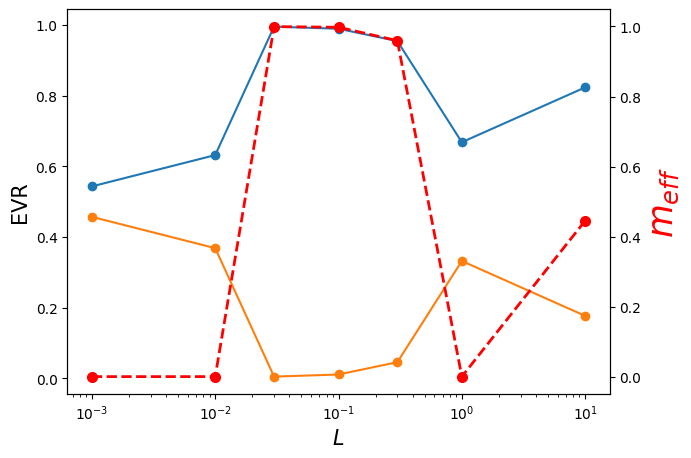

<Figure size 640x480 with 0 Axes>

In [8]:
# --------------------- Define helper function to compute effective rank (ERD) ---------------------
def f(x, a=2):
    n = x.shape[1]
    mask = x < 1 / (a * n)
    return np.sum(np.cos(np.pi / 2 * n * a * x) * mask, axis=1)

# --------------------- Plot explained variance and effective dimensionality ---------------------
plt.figure(figsize=(7, 5))

# Plot each PCA component’s explained variance
for i in range(input_dim):
    plt.plot(sigmals, exps[:, i], marker="o")

plt.xscale('log')
plt.xlabel(r"$L$", fontsize=15)
plt.ylabel("EVR", fontsize=15)

# Plot effective dimensionality (ERD) on second y-axis
ax2 = plt.gca().twinx()
ax2.plot(sigmals, f(exps, a=2), marker="o", color="red", linewidth=2, ls="--", markersize=7)
plt.ylabel(r"$m_{eff}$", fontsize=25, color="red")

# Save the plot to disk
plt.savefig('ERD.png', bbox_inches="tight")

plt.show()
plt.clf()

In [9]:
# Define a new neural network (as a list of layers) for each noise level
linears = [nn.Linear(nn_widths[i], nn_widths[i + 1]) for i in range(hidden_depth + 1)]
parameters = [p for layer in linears for p in layer.parameters()]  # Collect all trainable parameters

# Define loss function
criterion = nn.MSELoss()

# Choose optimizer
optimizer = optim.Adam(parameters, lr=lr) if opt == "Adam" else optim.SGD(parameters, lr=lr)

sigmal = .1
epoch = 500

# --------------------- Training the denoising network ---------------------
# (see in the Appendix below a step by step explanation of these steps)

for j in range(epoch):
    # Randomly sample a batch of training data
    choices = np.random.choice(n_train, batch_size)
    perturb = torch.normal(0, sigmal, size=(batch_size, input_dim))  # Add Gaussian noise
    inputs0 = torch.tensor(xs[choices], dtype=torch.float) + perturb  # Noisy input

    # Forward pass through each layer using LeakyReLU
    x = inputs0
    act = nn.LeakyReLU(slope)
    for i in range(hidden_depth):
        x = act(linears[i](x))
    outputs = linears[hidden_depth](x)  # Final layer (no activation)

    # Training objective: recover the *negative* of the noise added
    loss = criterion(outputs, -perturb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if j % 200 == 0:
        print(f"Epoch {j} | Loss: {loss:.4f}")

Epoch 0 | Loss: 0.0098
Epoch 200 | Loss: 0.0052
Epoch 400 | Loss: 0.0054


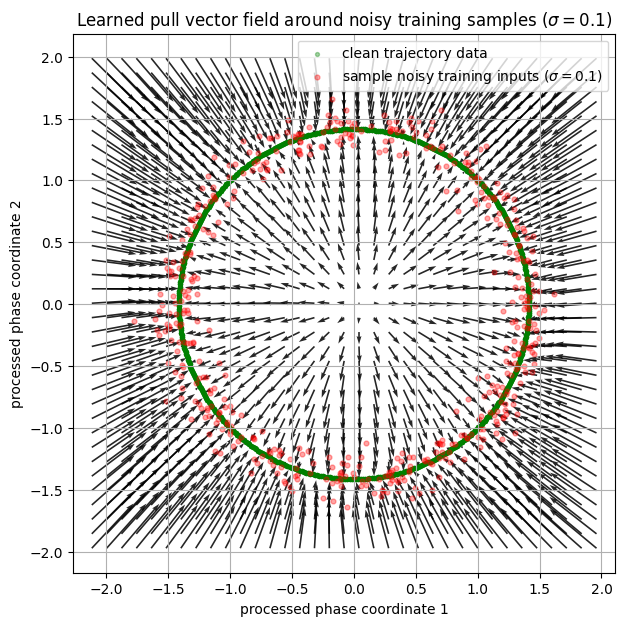

Saved: vector_field_large_grid.png


In [13]:
# --------------------- Vector-field visualization ---------------------
grid_size = 35

# ------------------------------------------------------------
# Create a representative set of noisy training samples
# (these are the actual type of inputs seen during training)
# ------------------------------------------------------------
rng = np.random.default_rng(seed)

n_vis_train = 500  # number of noisy training samples to display
vis_choices = rng.choice(n_train, size=n_vis_train, replace=True)
vis_noise = rng.normal(0.0, sigmal, size=(n_vis_train, input_dim))
train_vis_points = xs[vis_choices] + vis_noise

# Use the noisy training samples to define the visualization window
x_train_min, x_train_max = train_vis_points[:, 0].min(), train_vis_points[:, 0].max()
y_train_min, y_train_max = train_vis_points[:, 1].min(), train_vis_points[:, 1].max()

# Additional padding around the noisy sample cloud
padding_factor = 0.1

x_train_range = x_train_max - x_train_min
y_train_range = y_train_max - y_train_min

x_min = x_train_min - padding_factor * x_train_range
x_max = x_train_max + padding_factor * x_train_range
y_min = y_train_min - padding_factor * y_train_range
y_max = y_train_max + padding_factor * y_train_range

x_vals = np.linspace(x_min, x_max, grid_size)
y_vals = np.linspace(y_min, y_max, grid_size)
xv, yv = np.meshgrid(x_vals, y_vals)
grid_points = np.stack([xv.ravel(), yv.ravel()], axis=1)

# Pass grid points through network to get denoising vectors
with torch.no_grad():
    inputs = torch.tensor(grid_points, dtype=torch.float)
    x = inputs.clone()

    for i in range(hidden_depth):
        x = act(linears[i](x))

    outputs = linears[hidden_depth](x)

    # The output is the estimated negative noise:
    # it shows how the network would move a perturbed state back
    # toward the learned trajectory manifold.
    vectors = outputs.detach().cpu().numpy()

# Logarithmically scale vector lengths while preserving directions
magnitudes = np.linalg.norm(vectors, axis=1, keepdims=True)
eps = 1e-12
log_magnitudes = np.log1p(np.log1p(np.log1p(magnitudes)))

arrow_scale_factor = 1.0

vectors_log_scaled = (
    vectors / (magnitudes + eps)
    * log_magnitudes
    * arrow_scale_factor
)

plt.figure(figsize=(7, 7))

plt.quiver(
    grid_points[:, 0], grid_points[:, 1],
    vectors_log_scaled[:, 0], vectors_log_scaled[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.003,
    alpha=0.85
)

# Clean trajectory data
plt.scatter(
    xs[:, 0], xs[:, 1],
    s=8,
    alpha=0.35,
    color="green",
    label="clean trajectory data"
)

# Representative noisy training samples
plt.scatter(
    train_vis_points[:, 0], train_vis_points[:, 1],
    s=12,
    alpha=0.35,
    color="red",
    label=fr"sample noisy training inputs ($\sigma = {sigmal}$)"
)

plt.title(fr"Learned pull vector field around noisy training samples ($\sigma = {sigmal}$)")
plt.xlabel("processed phase coordinate 1")
plt.ylabel("processed phase coordinate 2")
plt.axis("equal")
plt.grid(True)
plt.legend(loc="best")

plt.savefig("vector_field_large_grid.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: vector_field_large_grid.png")

## Quantitative validation

The vector-field plot gives an intuitive picture, but it should not be treated as proof of a conservation law. The following two post-hoc validations ask whether the trained pull network has learned the expected physics of the undamped harmonic oscillator.

1. **Intrinsic-dimension validation:** after noisy points are pulled back by the network, local point clouds should become approximately one-dimensional, because a fixed-energy oscillator trajectory is an ellipse.
2. **Energy-consistency validation:** although energy was not used during training, corrected points should lie closer to the constant-energy curve than the noisy inputs.

These tests use physics only after training. They evaluate the learned representation; they do not supervise the network.

In [24]:
# --------------------- Validation helper functions ---------------------
# These functions reuse the trained pull network from the vector-field cell.

from sklearn.decomposition import PCA

# Oscillator parameters used only for post-hoc physics validation.
# These must match the data-generation notebook. If your data were generated
# with different values, change these two numbers.
m = 1.0
c = 1.0


def pull_vectors(points_processed):
    """Return the pull-network correction vectors for processed coordinates."""
    with torch.no_grad():
        t = torch.tensor(points_processed, dtype=torch.float)
        y = t.clone()
        for layer_idx in range(hidden_depth):
            y = act(linears[layer_idx](y))
        y = linears[hidden_depth](y)
    return y.detach().cpu().numpy()


def pull_back(points_processed):
    """Apply the learned correction to processed coordinates."""
    return points_processed + pull_vectors(points_processed)


def inverse_preprocess(points_processed):
    """Map processed coordinates back to the original raw phase-space coordinates [x, v]."""
    points_norm = preprocess_pca.inverse_transform(points_processed)
    return points_norm * raw_std[np.newaxis, :] + raw_mean[np.newaxis, :]


def processed_to_raw_jacobian():
    """Return the constant Jacobian J with row-vector convention: delta_raw = delta_processed @ J."""
    return preprocess_pca.components_ @ np.diag(raw_std)


def oscillator_energy(points_raw):
    """Mechanical energy H = 1/2 m v^2 + 1/2 c x^2 for raw coordinates [x, v]."""
    x = points_raw[:, 0]
    v = points_raw[:, 1]
    return 0.5 * m * v**2 + 0.5 * c * x**2


# Reference energy of the clean trajectory. Median is robust to small numerical noise.
H_clean = oscillator_energy(xs_raw)
E0 = np.median(H_clean)

print(f"Reference trajectory energy E0 ≈ {E0:.8f}")
print(f"Clean trajectory energy: mean |H-E0| = {np.mean(np.abs(H_clean - E0)):.3e}")
print(f"Clean trajectory energy: std(H) = {np.std(H_clean):.3e}")
print(f"Clean trajectory energy: min/max = {H_clean.min():.8f} / {H_clean.max():.8f}")


Reference trajectory energy E0 ≈ 1.00000000
Clean trajectory energy: mean |H-E0| = 3.576e-08
Clean trajectory energy: std(H) = 5.816e-08
Clean trajectory energy: min/max = 0.99999988 / 1.00000012


### Validation 1: local intrinsic dimension after pullback

For each selected trajectory point, the code samples a small cloud of nearby noisy points, applies the trained pull network, and performs PCA on the corrected cloud. If the network has learned the one-dimensional oscillator trajectory, the first principal direction should explain almost all remaining variance. The reported participation-ratio dimension is close to 1 for a line-like cloud and close to 2 for an area-like cloud.

In [25]:
# --------------------- Procedure 1: intrinsic-dimension validation ---------------------
rng = np.random.default_rng(seed)

n_centers = min(80, n_train)
n_local = 200
validation_noise = sigmal  # use the same scale as the final trained vector-field model

center_indices = rng.choice(n_train, size=n_centers, replace=False)
local_dims_pr = []
local_dims_95 = []
first_pc_ratios = []

for idx in center_indices:
    center = xs[idx:idx+1]
    noisy_cloud = center + rng.normal(0.0, validation_noise, size=(n_local, input_dim))
    pulled_cloud = pull_back(noisy_cloud)

    pca_local = PCA(n_components=input_dim)
    pca_local.fit(pulled_cloud)
    evr = pca_local.explained_variance_ratio_

    # Participation-ratio dimension: 1/sum(EVR_i^2).
    # For a nearly one-dimensional cloud this is close to 1.
    pr_dim = 1.0 / np.sum(evr**2)

    # Number of PCs needed to explain 95% of the variance.
    dim95 = int(np.searchsorted(np.cumsum(evr), 0.95) + 1)

    local_dims_pr.append(pr_dim)
    local_dims_95.append(dim95)
    first_pc_ratios.append(evr[0])

local_dims_pr = np.asarray(local_dims_pr)
local_dims_95 = np.asarray(local_dims_95)
first_pc_ratios = np.asarray(first_pc_ratios)

print("Procedure 1: local intrinsic-dimension validation")
print(f"  Mean participation-ratio dimension: {local_dims_pr.mean():.3f} ± {local_dims_pr.std():.3f}")
print(f"  Median number of PCs for 95% variance: {np.median(local_dims_95):.0f}")
print(f"  Mean variance explained by first PC: {first_pc_ratios.mean():.3f} ± {first_pc_ratios.std():.3f}")

if local_dims_pr.mean() < 1.25 and first_pc_ratios.mean() > 0.90:
    print("  Interpretation: strong evidence for an approximately one-dimensional learned manifold.")
elif local_dims_pr.mean() < 1.50 and first_pc_ratios.mean() > 0.75:
    print("  Interpretation: moderate evidence for dimensionality reduction, but the manifold is not very sharply recovered.")
else:
    print("  Interpretation: weak evidence; the pullback clouds remain too area-like to support a clear 1-D manifold claim.")

Procedure 1: local intrinsic-dimension validation
  Mean participation-ratio dimension: 1.037 ± 0.021
  Median number of PCs for 95% variance: 1
  Mean variance explained by first PC: 0.982 ± 0.010
  Interpretation: strong evidence for an approximately one-dimensional learned manifold.


### Validation 2: energy consistency of corrected states

The pull network is trained in **processed coordinates**, while the oscillator energy is defined in the original raw coordinates `[x, v]`. Therefore the validation must use the original preprocessing inverse transform, not a diagnostic PCA object from another cell.

The diagnostic below checks three things:

1. whether the clean trajectory really has nearly constant energy,
2. whether the learned pullback reduces the raw energy error relative to the noisy inputs,
3. whether the learned correction points toward decreasing/increasing energy in the processed coordinate metric used by the network.

The directional alignment is computed in processed coordinates. This is the appropriate geometry because the network sees isotropic Gaussian noise in processed coordinates, not in raw physical coordinates.


Procedure 2: energy-consistency validation
  Clean baseline mean |H(clean)-E0|:       1.200140e-07
  Mean |H(noisy) - E0|:                  1.114475e-01
  Mean |H(corrected) - E0|:              1.862595e-02
  Mean |H(analytic projection)-E0|:      1.093015e-16
  Relative energy-error reduction:       0.833
  Mean processed correction/energy-normal alignment: 0.898 ± 0.197
  Interpretation: strong evidence that the learned pull field is consistent with the constant-energy manifold.


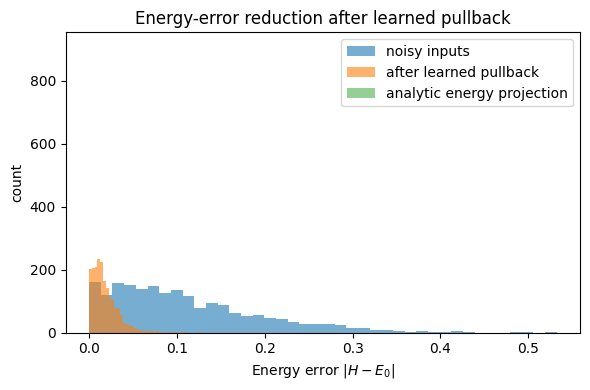

Saved: energy_error_validation.png


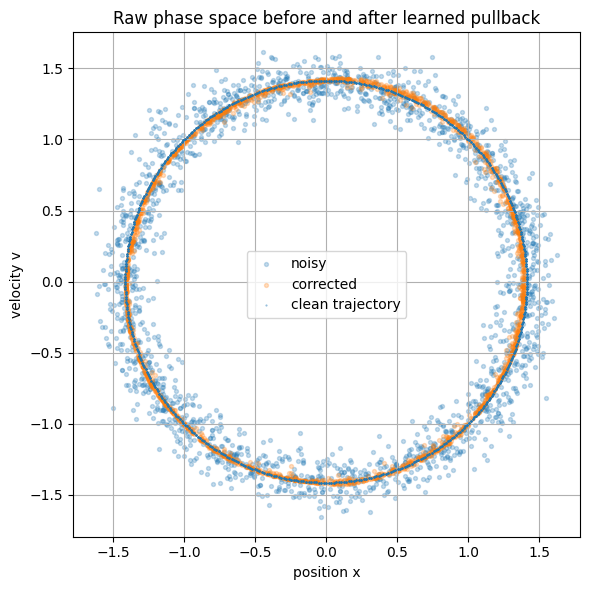

Saved: raw_phase_pullback_validation.png


In [26]:
# --------------------- Procedure 2: energy-consistency validation ---------------------
n_val = min(2000, n_train)
val_indices = rng.choice(n_train, size=n_val, replace=False)

clean_processed = xs[val_indices]
noisy_processed = clean_processed + rng.normal(0.0, validation_noise, size=clean_processed.shape)
corrected_processed = pull_back(noisy_processed)

# Convert all relevant states back to raw physical coordinates using the ORIGINAL preprocessing PCA.
clean_raw = inverse_preprocess(clean_processed)
noisy_raw = inverse_preprocess(noisy_processed)
corrected_raw = inverse_preprocess(corrected_processed)

H_clean_val = oscillator_energy(clean_raw)
H_noisy = oscillator_energy(noisy_raw)
H_corrected = oscillator_energy(corrected_raw)

energy_error_clean = np.abs(H_clean_val - E0)
energy_error_noisy = np.abs(H_noisy - E0)
energy_error_corrected = np.abs(H_corrected - E0)

mean_noisy = energy_error_noisy.mean()
mean_corrected = energy_error_corrected.mean()
energy_error_reduction = 1.0 - mean_corrected / mean_noisy if mean_noisy > 0 else np.nan

# Analytic reference: exact radial projection to the same quadratic energy level.
# This is not used for training; it is just a sanity check for the scale of possible improvement.
def project_to_energy_level(points_raw, E0, eps=1e-12):
    H = oscillator_energy(points_raw)
    scale = np.sqrt(E0 / np.maximum(H, eps))
    return points_raw * scale[:, None]

projected_raw = project_to_energy_level(noisy_raw, E0)
H_projected = oscillator_energy(projected_raw)
energy_error_projected = np.abs(H_projected - E0)

# Directional check in the geometry in which the network was trained.
# The network correction is a vector in processed coordinates. The corresponding
# energy gradient in processed coordinates is grad_z H = J^T grad_raw H, where
# delta_raw = delta_processed @ J.
correction_processed = corrected_processed - noisy_processed
J = processed_to_raw_jacobian()
gradH_raw = np.column_stack([c * noisy_raw[:, 0], m * noisy_raw[:, 1]])
gradH_processed = gradH_raw @ J.T

target_direction_processed = -np.sign(H_noisy - E0)[:, None] * gradH_processed

norm_corr = np.linalg.norm(correction_processed, axis=1)
norm_target = np.linalg.norm(target_direction_processed, axis=1)
valid = (
    (norm_corr > 1e-12)
    & (norm_target > 1e-12)
    & (energy_error_noisy > np.percentile(energy_error_noisy, 10))
)

if np.any(valid):
    cos_alignment_processed = (
        np.sum(correction_processed[valid] * target_direction_processed[valid], axis=1)
        / (norm_corr[valid] * norm_target[valid])
    )
    mean_alignment = cos_alignment_processed.mean()
    std_alignment = cos_alignment_processed.std()
else:
    cos_alignment_processed = np.array([])
    mean_alignment = np.nan
    std_alignment = np.nan

print("Procedure 2: energy-consistency validation")
print(f"  Clean baseline mean |H(clean)-E0|:       {energy_error_clean.mean():.6e}")
print(f"  Mean |H(noisy) - E0|:                  {mean_noisy:.6e}")
print(f"  Mean |H(corrected) - E0|:              {mean_corrected:.6e}")
print(f"  Mean |H(analytic projection)-E0|:      {energy_error_projected.mean():.6e}")
print(f"  Relative energy-error reduction:       {energy_error_reduction:.3f}")
print(f"  Mean processed correction/energy-normal alignment: {mean_alignment:.3f} ± {std_alignment:.3f}")

if energy_error_clean.mean() > 1e-4 * max(abs(E0), 1.0):
    print("  Warning: the clean data are not exactly on a single energy level; check m, c, and the data file.")

if energy_error_reduction > 0.70 and mean_alignment > 0.70:
    print("  Interpretation: strong evidence that the learned pull field is consistent with the constant-energy manifold.")
elif energy_error_reduction > 0.40 and mean_alignment > 0.40:
    print("  Interpretation: moderate evidence; the network improves energy consistency, but the learned field is imperfect.")
elif energy_error_reduction > 0.0:
    print("  Interpretation: weak-to-moderate evidence; the network reduces energy error, but it should not yet be interpreted as a clean energy projection.")
else:
    print("  Interpretation: weak evidence; the learned pullback does not improve energy consistency for this validation setting.")

# Compact visualization for the notebook
plt.figure(figsize=(6, 4))
plt.hist(energy_error_noisy, bins=40, alpha=0.6, label="noisy inputs")
plt.hist(energy_error_corrected, bins=40, alpha=0.6, label="after learned pullback")
plt.hist(energy_error_projected, bins=40, alpha=0.5, label="analytic energy projection")
plt.xlabel(r"Energy error $|H - E_0|$")
plt.ylabel("count")
plt.title("Energy-error reduction after learned pullback")
plt.legend()
plt.tight_layout()
plt.savefig("energy_error_validation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: energy_error_validation.png")

# Optional phase-space diagnostic: corrected points should move closer to the clean energy contour.
plt.figure(figsize=(6, 6))
plt.scatter(noisy_raw[:, 0], noisy_raw[:, 1], s=8, alpha=0.25, label="noisy")
plt.scatter(corrected_raw[:, 0], corrected_raw[:, 1], s=8, alpha=0.25, label="corrected")
plt.plot(xs_raw[:, 0], xs_raw[:, 1], ".", markersize=1, alpha=0.5, label="clean trajectory")
plt.xlabel("position x")
plt.ylabel("velocity v")
plt.title("Raw phase space before and after learned pullback")
plt.axis("equal")
plt.grid(True)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("raw_phase_pullback_validation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: raw_phase_pullback_validation.png")
